<a href="https://colab.research.google.com/github/rahul7762/credit-card-segmentation/blob/main/EDA_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

print("Path to dataset files:", path)

100%|██████████| 340k/340k [00:00<00:00, 26.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/arjunbhasin2013/ccdata/versions/1


In [ ]:
import os
csv_file = os.path.join(path, "CC GENERAL.csv")
df = pd.read_csv(csv_file)

In [ ]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


#Column Type

Numarical:-BALANCE	,BALANCE_FREQUENCY....all other is numarical

Mixed:-	CUST_ID

In [ ]:
print("Missing values before cleaning:\n")
df.isnull().sum()

Missing values before cleaning:



,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
#The CUST_ID is hardly ever used so we drop it temporarily
df = df.drop('CUST_ID', axis=1)

In [ ]:
#fill missing value to median
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [ ]:
#checking 100% value is fille by median or not
print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nFinal Data Shape:", df.shape)


Missing values after cleaning:
 BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

Final Data Shape: (8950, 17)


In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


#BALANCE

In [ ]:
df['BALANCE'].describe()

,BALANCE
count,8950.000000
mean,1564.474828
std,2081.531879
min,0.000000
25%,128.281915
50%,873.385231
75%,2054.140036
max,19043.138560


Text(0.5, 0.98, 'Histograms of Selected Features')

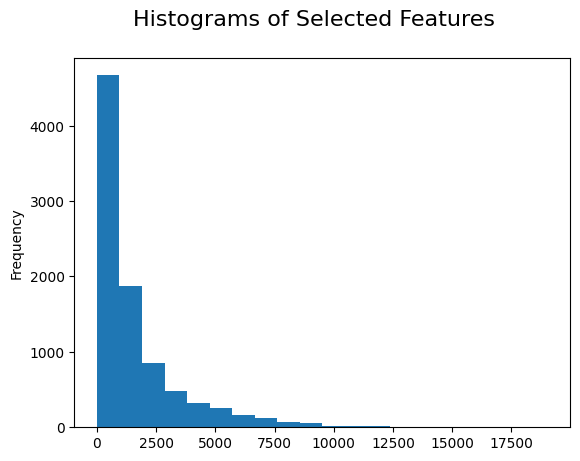

In [ ]:
df['BALANCE'].plot(kind='hist',bins=20)
plt.suptitle('Histograms of Selected Features', fontsize=16)

<Axes: ylabel='Density'>

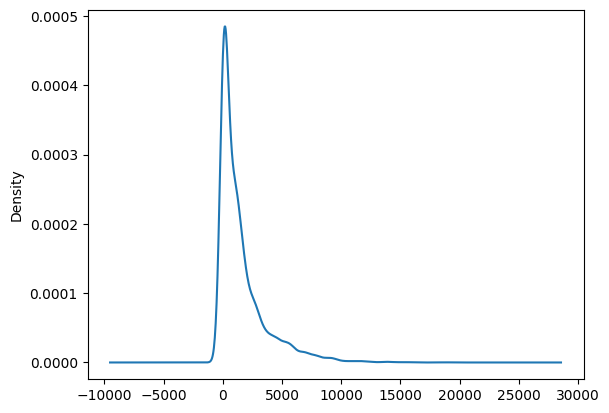

In [ ]:
df['BALANCE'].plot(kind='kde')

In [ ]:
df['BALANCE'].skew()

np.float64(2.393386042571806)

Text(0.5, 1.0, 'Boxplots for Outlier Detection')

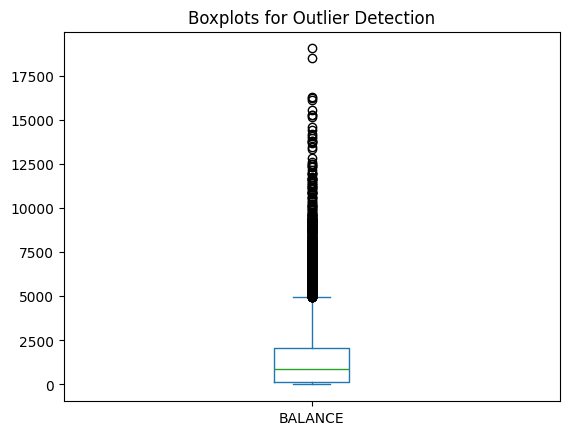

In [ ]:
df['BALANCE'].plot(kind='box')
plt.title('Boxplots for Outlier Detection')

In [ ]:
df[df['BALANCE'] >14500]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
138,19043.13856,1.0,22009.92,9449.07,12560.85,0.000000,1.000000,0.750000,1.000000,0.000000,0,216,18000.0,23018.575830,18621.013310,0.0,12
520,15258.22590,1.0,529.30,529.30,0.00,4100.891579,0.500000,0.500000,0.000000,1.000000,23,10,19000.0,2051.146470,3905.740148,0.0,8
585,15244.74865,1.0,7823.74,7564.81,258.93,2621.049473,1.000000,1.000000,1.000000,0.083333,2,62,19000.0,11123.409180,4467.520244,0.0,12
883,14581.45914,1.0,0.00,0.00,0.00,22665.778500,0.000000,0.000000,0.000000,0.833333,30,0,18500.0,20941.325510,5433.759888,0.0,12
2361,15532.33972,1.0,1168.75,0.00,1168.75,3183.037625,0.916667,0.000000,0.916667,0.250000,5,11,16500.0,3906.738592,3379.593046,0.0,12
4140,18495.55855,1.0,5288.28,3657.30,1630.98,0.000000,1.000000,0.583333,1.000000,0.000000,0,76,22000.0,4246.168346,4227.081580,0.0,12
4708,15155.53286,1.0,717.24,717.24,0.00,4718.274895,1.000000,1.000000,0.000000,0.500000,7,24,18000.0,4002.194556,3843.924668,0.0,12
5281,16115.59640,1.0,684.74,105.30,579.44,4354.002428,1.000000,0.083333,1.000000,0.583333,15,15,18000.0,3546.061550,5743.736444,0.0,12
5488,16304.88925,1.0,1770.57,0.00,1770.57,7424.094447,0.500000,0.000000,0.416667,0.666667,13,9,19000.0,5337.961195,8345.641905,0.0,12
6629,16259.44857,1.0,5024.68,3582.45,1442.23,328.698275,1.000000,0.833333,1.000000,0.083333,2,143,18000.0,4987.235359,5137.504664,0.0,12


**Conclusion**
*   most of custumer bilance is 0-2500
*   Highily Positively (Right)Skewed
*   There are some outliers

##PURCHASES

In [ ]:
df['PURCHASES'].describe()

,PURCHASES
count,8950.000000
mean,1003.204834
std,2136.634782
min,0.000000
25%,39.635000
50%,361.280000
75%,1110.130000
max,49039.570000


Text(0.5, 0.98, 'Histograms of Selected Features')

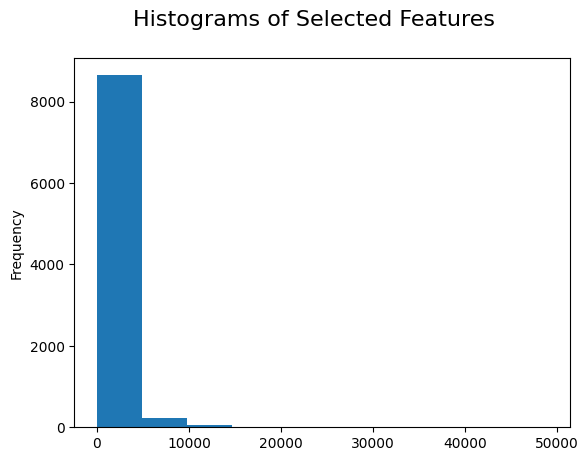

In [ ]:
df['PURCHASES'].plot(kind='hist')
plt.suptitle('Histograms of Selected Features', fontsize=16)

<Axes: ylabel='Density'>

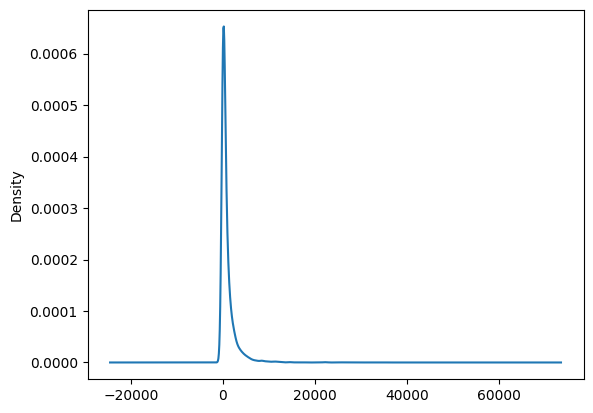

In [ ]:
df['PURCHASES'].plot(kind='kde')

In [ ]:
df['PURCHASES'].skew()

np.float64(8.144269064554651)

Text(0.5, 1.0, 'Boxplots for Outlier Detection')

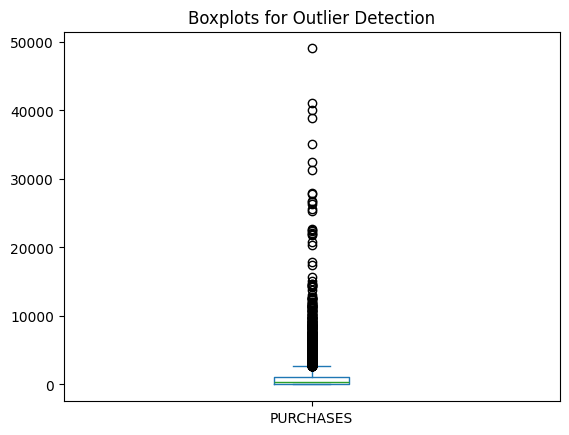

In [ ]:
df['PURCHASES'].plot(kind='box')
plt.title('Boxplots for Outlier Detection')

In [ ]:
df[df['PURCHASES']>8000]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
125,2392.917738,1.000000,12462.44,12462.44,0.00,0.000000,0.916667,0.916667,0.000000,0.000000,0,217,2800.0,11628.715570,2000.990921,0.000000,12
138,19043.138560,1.000000,22009.92,9449.07,12560.85,0.000000,1.000000,0.750000,1.000000,0.000000,0,216,18000.0,23018.575830,18621.013310,0.000000,12
153,13673.079610,1.000000,9792.23,3959.81,5832.42,2444.445738,1.000000,0.750000,1.000000,0.750000,26,216,20000.0,11717.307940,6042.391629,0.000000,12
171,975.942008,1.000000,10221.35,7141.38,3079.97,1620.685551,1.000000,1.000000,0.833333,0.583333,18,130,10500.0,10693.495850,347.641073,0.750000,12
204,4559.779234,1.000000,10848.50,8208.00,2640.50,0.000000,1.000000,0.666667,1.000000,0.000000,0,123,7500.0,9423.715495,2925.275522,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7277,561.003319,1.000000,11577.00,10975.00,602.00,875.583070,1.000000,1.000000,0.500000,0.250000,6,97,5500.0,12148.503510,188.413837,0.666667,12
7378,4228.417754,1.000000,11994.71,11994.71,0.00,496.521561,0.250000,0.250000,0.000000,0.083333,2,8,13450.0,508.797444,1725.645623,0.000000,12
7553,2017.391656,1.000000,12024.37,11224.10,800.27,0.000000,1.000000,1.000000,0.500000,0.000000,0,133,8000.0,11516.392320,556.651236,0.333333,12
8541,3326.323283,1.000000,8209.77,2218.28,5991.49,0.000000,1.000000,0.416667,1.000000,0.000000,0,130,10000.0,1942.074765,702.905059,0.083333,12


**Conclusin**


*    The PURCHASES data is not normally distributed most of the values are concentrated in the lower range
*   The distribution is highly positively skewed (right-skewed) the skewness value is approximately 8.14, which indicates strong right skewness.

*   The box plot clearly shows a large number of high-value outliers these represent customers whose purchase amounts are significantly higher than the majority.
*   Both the histogram and KDE plot show a long right tail, confirming that a small number of customers have very high purchase values.


*   Overall, the PURCHASES variable contains a highly right-skewed distribution with several extreme outliers most customers have relatively low purchase amounts, while only a small number of customers have exceptionally high purchases.

#CASH_ADVANCE, CREDIT_LIMIT

In [ ]:
#slicing
df_selected =df[['CASH_ADVANCE', 'CREDIT_LIMIT']]

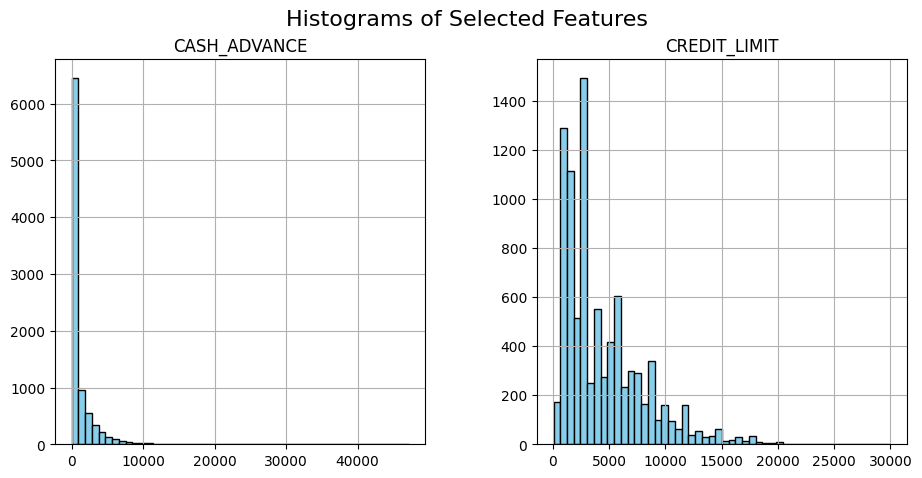

In [ ]:
df_selected.hist(bins=50, figsize=(11, 5), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Selected Features', fontsize=16)
plt.show()

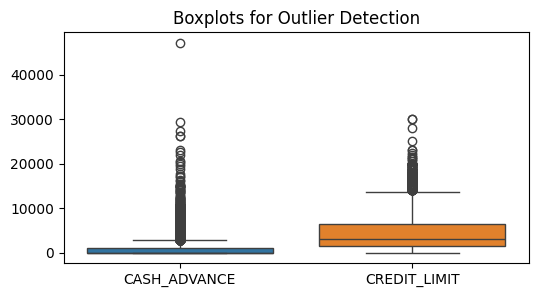

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df_selected[['CASH_ADVANCE', 'CREDIT_LIMIT']])
plt.title('Boxplots for Outlier Detection')
plt.show()

In [ ]:
df_selected.describe()

,CASH_ADVANCE,CREDIT_LIMIT
count,8950.000000,8950.000000
mean,978.871112,4494.282473
std,2097.163877,3638.646702
min,0.000000,50.000000
25%,0.000000,1600.000000
50%,0.000000,3000.000000
75%,1113.821139,6500.000000
max,47137.211760,30000.000000


**conculision**

*   Overall, the analysis shows significant variation in customer financial behavior and credit capacity. The presence of extreme values is important for customer segmentation, as these values may help identify different groups of customers based on their cash advance usage and credit limits.

#Bivariate Analysis

In [ ]:
df_selected =df[['BALANCE', 'PURCHASES','CASH_ADVANCE', 'CREDIT_LIMIT']]

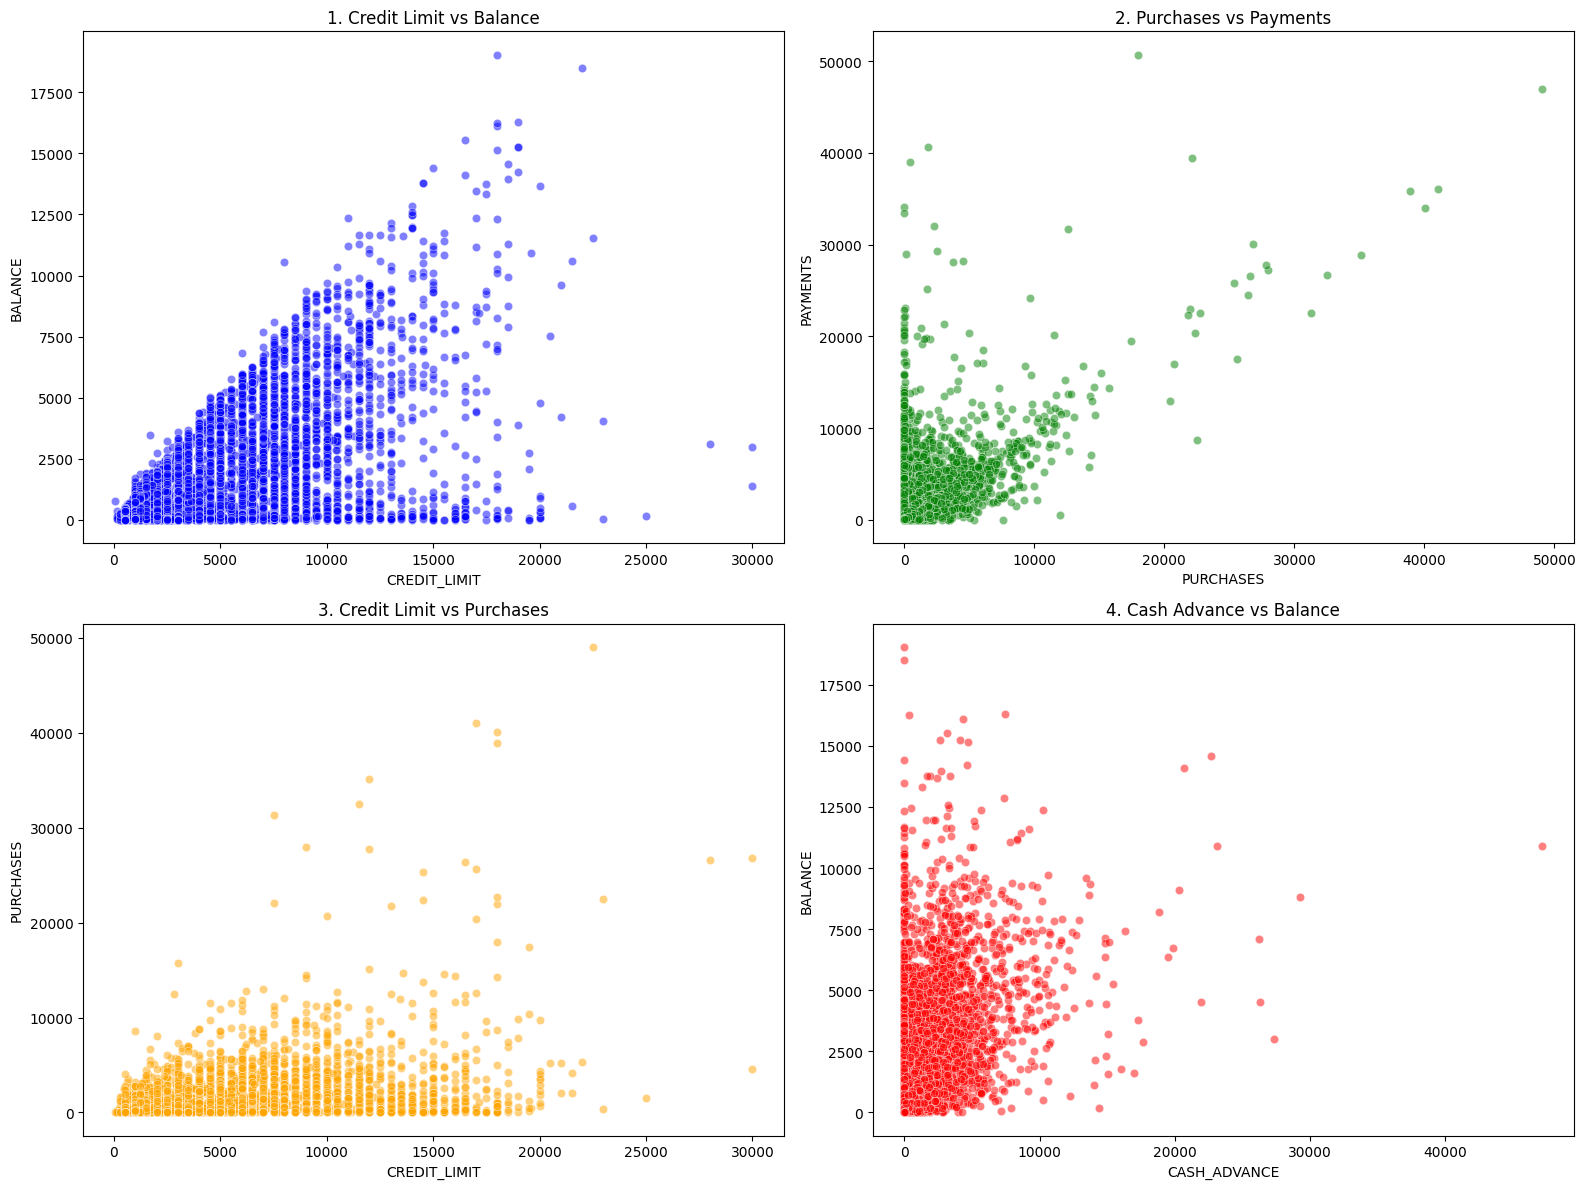

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Credit Limit vs Balance
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='BALANCE', ax=axes[0, 0], alpha=0.5, color='blue')
axes[0, 0].set_title('1. Credit Limit vs Balance')

#Purchases vs Payments
sns.scatterplot(data=df, x='PURCHASES', y='PAYMENTS', ax=axes[0, 1], alpha=0.5, color='green')
axes[0, 1].set_title('2. Purchases vs Payments')

#Credit Limit vs Purchases
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', ax=axes[1, 0], alpha=0.5, color='orange')
axes[1, 0].set_title('3. Credit Limit vs Purchases')

#Cash Advance vs Balance
sns.scatterplot(data=df, x='CASH_ADVANCE', y='BALANCE', ax=axes[1, 1], alpha=0.5, color='red')
axes[1, 1].set_title('4. Cash Advance vs Balance')

plt.tight_layout()
plt.show()

# Heatmap

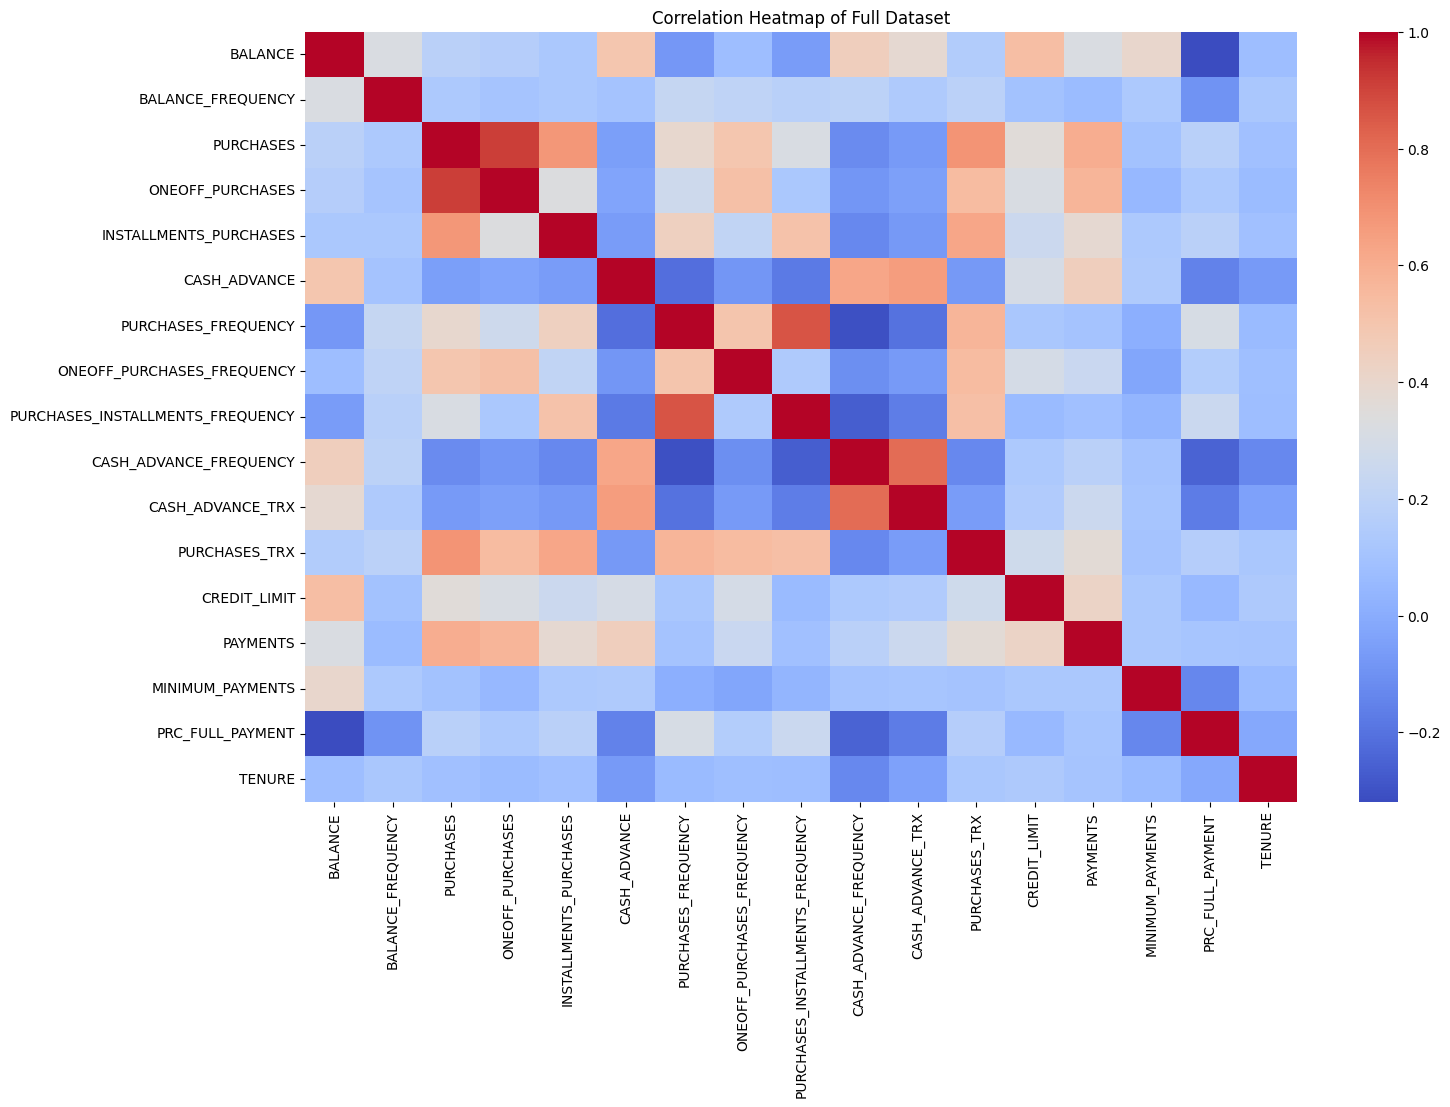

In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')

plt.title('Correlation Heatmap of Full Dataset')
plt.show()

#conclusion
Purchases vs. Payments: Shows a strong positive correlation, but a distinct group makes high payments with zero purchases, indicating customers who are strictly paying off old debt.

Credit Limit vs. Purchases: A high credit limit does not guarantee high spending. The vast majority of customers make small purchases regardless of their available limit.

Cash Advance vs. Balance: Customers utilizing cash advances show a rapid increase in their overall balances. However, a dense cluster strictly avoids cash advances entirely.

Credit Limit vs. Balance: There is no predictable relationship. Customers with identical credit limits exhibit completely scattered balance behaviors, ranging from zero to fully maxed out.

#Feature Eng





#Add two new coloumn
 CREDIT_UTILIZATION

  PAYMENT_RATIO

*  CREDIT_UTILIZATION (Balance / Credit Limit): Raw balances do not reflect actual risk A ₹10000 balance is risky if the limit is ₹12000 (83% utilization) but safe if the limit is ₹100000 (10% utilization) This ratio standardizes credit dependency.

*  PAYMENT_RATIO (Payments / Minimum Payments):- This identifies repayment behavior It clearly differentiates "**Full-Payers**" (who clear their total bills) from "**Revolvers**" (who only pay the minimum due and generate interest).

*  The + 0.0001 Math Trick:- Added to the denominator when calculating PAYMENT_RATIO Since some customers had a minimum payment of exactly 0, adding this tiny value prevents a fatal ZeroDivisionError without altering the data integrity.

*  Future Impact on the Project: In the upcoming clustering phase these ratios will train the machine learning algorithm to group customers based on their financial habits rather than just raw transaction volumes leading to highly actionable business segments (ex:- VIPs vs. High-Debt Users).

In [ ]:

important_features = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'CREDIT_LIMIT',
    'PAYMENTS', 'PRC_FULL_PAYMENT'
]
df_selected = df[important_features].copy()
df_selected['CREDIT_UTILIZATION'] = df_selected['BALANCE'] / df_selected['CREDIT_LIMIT']
df_selected['PAYMENT_RATIO'] = df_selected['PAYMENTS'] / (df['MINIMUM_PAYMENTS'] + 0.0001)
print(df_selected[['CREDIT_UTILIZATION', 'PAYMENT_RATIO']].head())

   CREDIT_UTILIZATION  PAYMENT_RATIO
0            0.040901       1.446507
1            0.457495       3.826241
2            0.332687       0.991681
3            0.222223       0.000000
4            0.681429       2.771073


In [ ]:
df_selected.head()

,BALANCE,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,CREDIT_UTILIZATION,PAYMENT_RATIO
0,40.900749,95.40,0.000000,0.166667,0.000000,2,1000.0,201.802084,0.000000,0.040901,1.446507
1,3202.467416,0.00,6442.945483,0.000000,0.250000,0,7000.0,4103.032597,0.222222,0.457495,3.826241
2,2495.148862,773.17,0.000000,1.000000,0.000000,12,7500.0,622.066742,0.000000,0.332687,0.991681
3,1666.670542,1499.00,205.788017,0.083333,0.083333,1,7500.0,0.000000,0.000000,0.222223,0.000000
4,817.714335,16.00,0.000000,0.083333,0.000000,1,1200.0,678.334763,0.000000,0.681429,2.771073
